In [ ]:
import pandas as pd

file_path = "/content/credit_card_fraud_dataset.csv"
df = pd.read_csv(file_path)
print(df.head())

   TransactionID             TransactionDate   Amount  MerchantID  \
0              1  2024-04-03 14:15:35.462794  4189.27         688   
1              2  2024-03-19 13:20:35.462824  2659.71         109   
2              3  2024-01-08 10:08:35.462834   784.00         394   
3              4  2024-04-13 23:50:35.462850  3514.40         944   
4              5  2024-07-12 18:51:35.462858   369.07         475   

  TransactionType      Location  IsFraud  
0          refund   San Antonio        0  
1          refund        Dallas        0  
2        purchase      New York        0  
3        purchase  Philadelphia        0  
4        purchase       Phoenix        0  


### Data Cleaning and Preprocessing

First, let's check for missing values in the dataset.

In [ ]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64


Next, let's examine the data types of each column and convert `TransactionDate` to a datetime object.

In [ ]:
print("\nOriginal data types:\n")
df.info()
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
print("\nData types after converting 'TransactionDate':\n")
df.info()


Original data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB

Data types after converting 'TransactionDate':

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[ns]
 2   Amou

Finally, let's look at the summary statistics for the numerical columns to understand their distribution.

In [ ]:
print("\nSummary statistics for numerical columns:\n")
print(df.describe())


Summary statistics for numerical columns:

       TransactionID                TransactionDate         Amount  \
count  100000.000000                         100000  100000.000000   
mean    50000.500000  2024-04-21 13:06:09.973745920    2497.092666   
min         1.000000     2023-10-21 09:28:35.824439       1.050000   
25%     25000.750000  2024-01-20 23:18:20.586056704    1247.955000   
50%     50000.500000  2024-04-21 13:39:35.701438976    2496.500000   
75%     75000.250000  2024-07-21 22:28:05.702624512    3743.592500   
max    100000.000000     2024-10-21 09:20:35.961088    4999.770000   
std     28867.657797                            NaN    1442.415999   

          MerchantID        IsFraud  
count  100000.000000  100000.000000  
mean      501.676070       0.010000  
min         1.000000       0.000000  
25%       252.000000       0.000000  
50%       503.000000       0.000000  
75%       753.000000       0.000000  
max      1000.000000       1.000000  
std       288.715868 

### Exploratory Data Analysis (EDA)

Let's start by visualizing the distribution of transaction amounts.

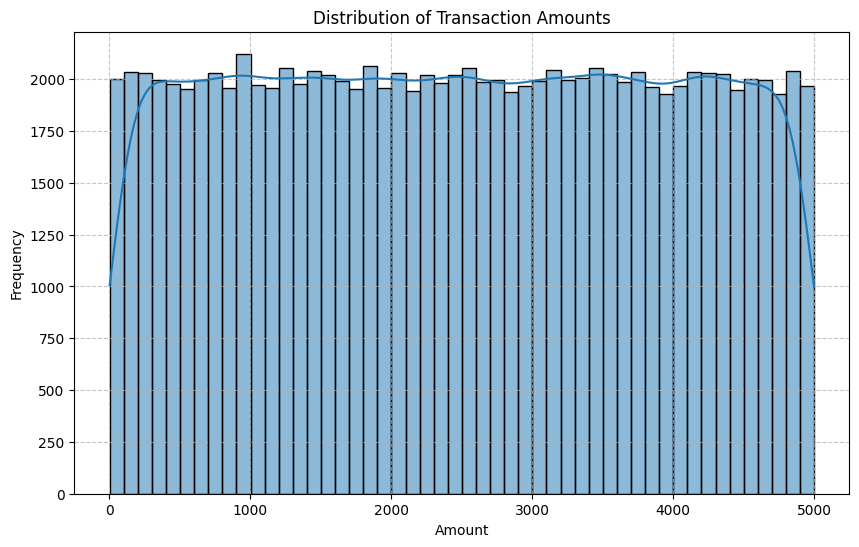

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Next, let's examine the count of fraudulent versus non-fraudulent transactions.

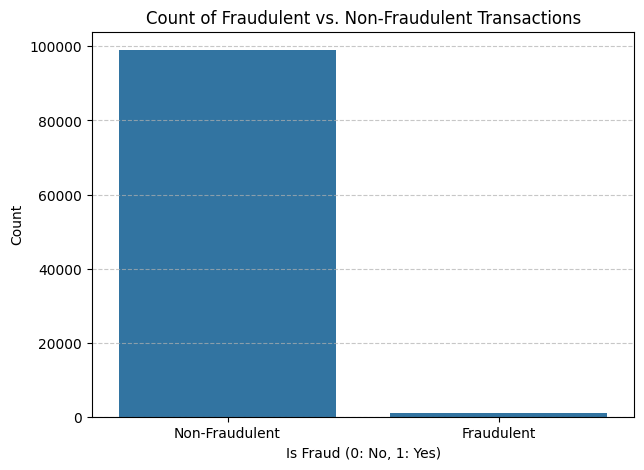

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='IsFraud', data=df)
plt.title('Count of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Now, let's look at the fraud rate by `TransactionType`.

/tmp/ipykernel_8086/3532060611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TransactionType', y='Fraud_Rate', data=fraud_by_type, palette='viridis')


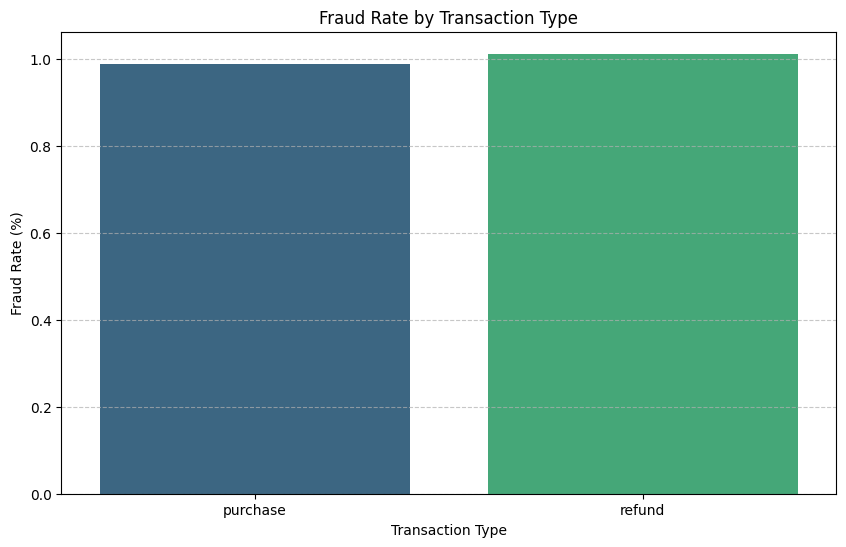

In [ ]:
fraud_by_type = df.groupby('TransactionType')['IsFraud'].mean().reset_index()
fraud_by_type['Fraud_Rate'] = fraud_by_type['IsFraud'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='TransactionType', y='Fraud_Rate', data=fraud_by_type, palette='viridis')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Let's investigate the top locations with fraudulent transactions.

/tmp/ipykernel_8086/1867717898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fraud_Count', y='Location', data=fraud_by_location, palette='magma')


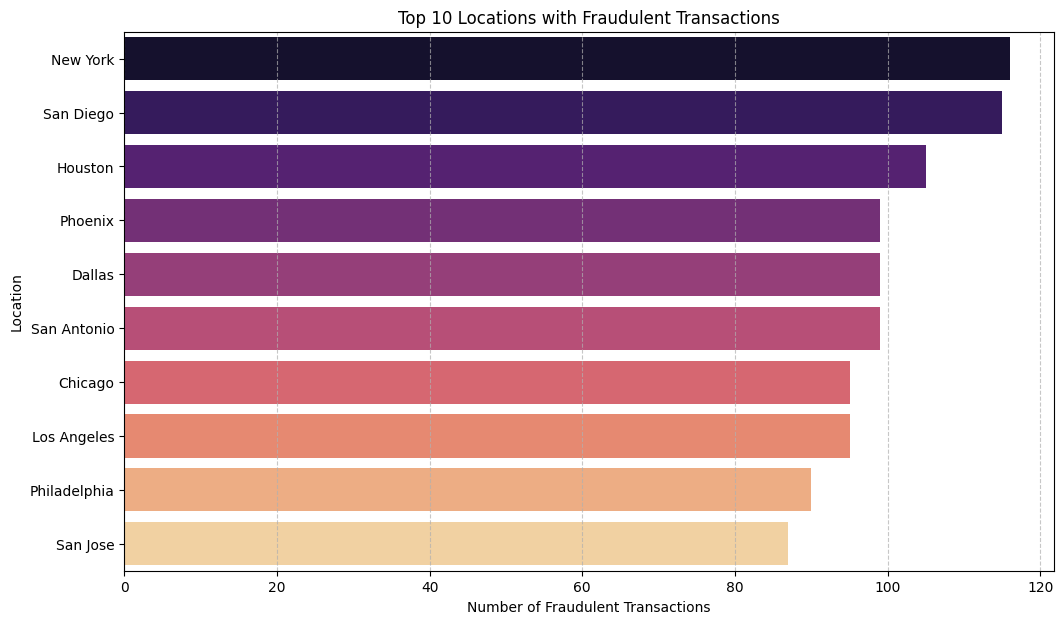

In [ ]:
fraud_by_location = df[df['IsFraud'] == 1]['Location'].value_counts().head(10).reset_index()
fraud_by_location.columns = ['Location', 'Fraud_Count']

plt.figure(figsize=(12, 7))
sns.barplot(x='Fraud_Count', y='Location', data=fraud_by_location, palette='magma')
plt.title('Top 10 Locations with Fraudulent Transactions')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Finally, let's observe the trend of transactions over time.

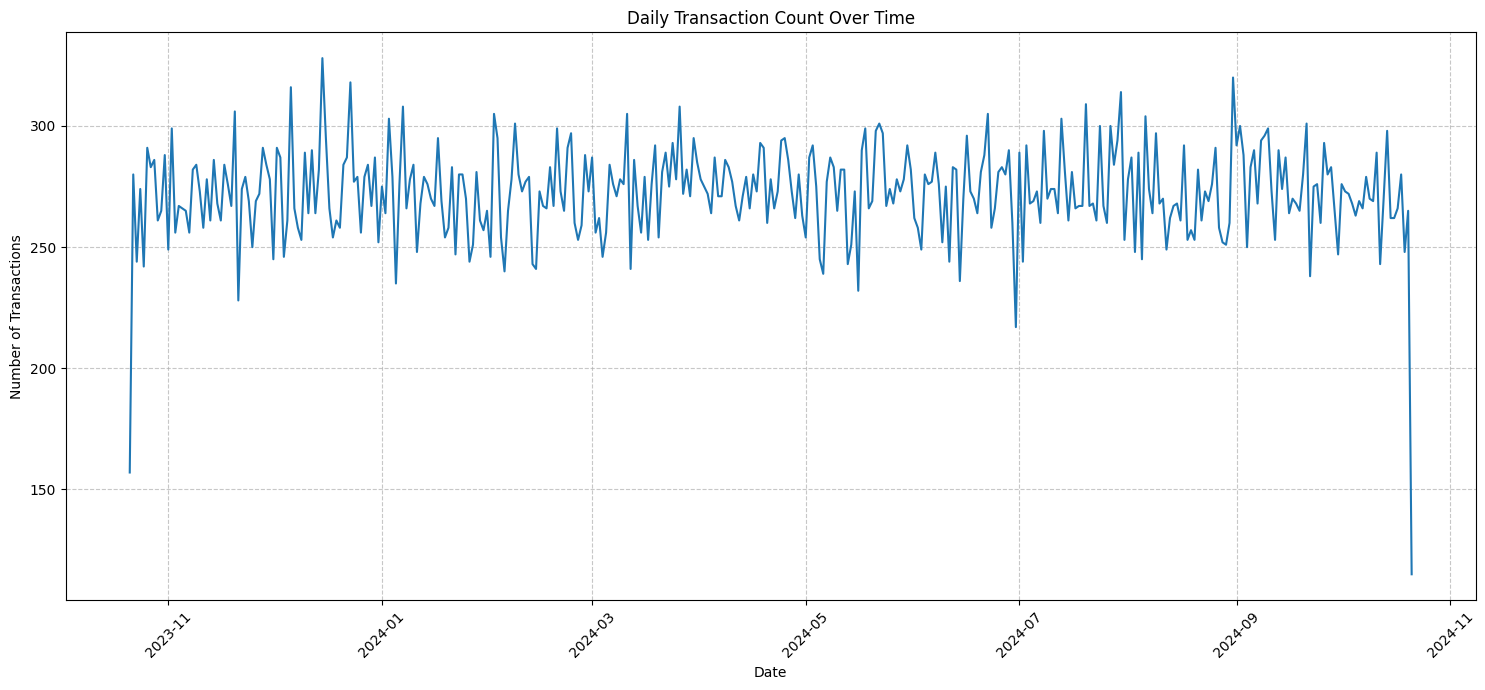

In [ ]:
df['Date'] = df['TransactionDate'].dt.date
daily_transactions = df.groupby('Date').size().reset_index(name='Transaction_Count')
daily_transactions['Date'] = pd.to_datetime(daily_transactions['Date'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Transaction_Count', data=daily_transactions)
plt.title('Daily Transaction Count Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Engineering and Selection

First, let's extract time-based features from the `TransactionDate` column to capture potential temporal patterns.

In [ ]:
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['TransactionMonth'] = df['TransactionDate'].dt.month

print("DataFrame with new time-based features:")
print(df[['TransactionDate', 'TransactionHour', 'TransactionDayOfWeek', 'TransactionMonth']].head())

DataFrame with new time-based features:
             TransactionDate  TransactionHour  TransactionDayOfWeek  \
0 2024-04-03 14:15:35.462794               14                     2   
1 2024-03-19 13:20:35.462824               13                     1   
2 2024-01-08 10:08:35.462834               10                     0   
3 2024-04-13 23:50:35.462850               23                     5   
4 2024-07-12 18:51:35.462858               18                     4   

   TransactionMonth  
0                 4  
1                 3  
2                 1  
3                 4  
4                 7  


Next, we will convert categorical features (`TransactionType` and `Location`) into numerical representations using one-hot encoding. We will also drop the original categorical columns and `TransactionID` as it's an identifier, and `Date` which was created for visualization.

In [ ]:
df = pd.get_dummies(df, columns=['TransactionType', 'Location'], drop_first=True)

# Drop columns that are no longer needed for modeling or are redundant
df = df.drop(columns=['TransactionID', 'TransactionDate', 'Date'])

print("\nDataFrame after one-hot encoding and dropping columns:")
print(df.head())


DataFrame after one-hot encoding and dropping columns:
    Amount  MerchantID  IsFraud  TransactionHour  TransactionDayOfWeek  \
0  4189.27         688        0               14                     2   
1  2659.71         109        0               13                     1   
2   784.00         394        0               10                     0   
3  3514.40         944        0               23                     5   
4   369.07         475        0               18                     4   

   TransactionMonth  TransactionType_refund  Location_Dallas  \
0                 4                    True            False   
1                 3                    True             True   
2                 1                   False            False   
3                 4                   False            False   
4                 7                   False            False   

   Location_Houston  Location_Los Angeles  Location_New York  \
0             False                 False         

### Model Selection and Evaluation

Now, let's prepare the data for machine learning, select a few candidate models, train them, and evaluate their accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Define features (X) and target (y)
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Fraudulent transactions in training set: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraudulent transactions in test set: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Shape of X_train: (70000, 15)
Shape of y_train: (70000,)
Shape of X_test: (30000, 15)
Shape of y_test: (30000,)
Fraudulent transactions in training set: 700 (1.00%)
Fraudulent transactions in test set: 300 (1.00%)


Given the class imbalance, we will use `class_weight='balanced'` for Logistic Regression and `scale_pos_weight` for tree-based models where applicable, or consider sampling techniques for better performance. Here, we'll start by training and evaluating a few models.

In [ ]:
# Initialize and train Logistic Regression
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg)

print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")


--- Logistic Regression ---
Accuracy: 0.5407
Precision: 0.0095
Recall: 0.4333
F1-Score: 0.0185
ROC-AUC: 0.4753


In [ ]:
# Initialize and train Random Forest Classifier
print("\n--- Random Forest Classifier ---")
# Calculate class weights for imbalanced dataset
class_weights = len(y_train) / (2 * np.bincount(y_train))
rf_class_weights = {0: class_weights[0], 1: class_weights[1]}

rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight=rf_class_weights, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")


--- Random Forest Classifier ---
Accuracy: 0.9900
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.5095


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Initialize and train Gradient Boosting Classifier
print("\n--- Gradient Boosting Classifier ---")
# For Gradient Boosting, we can use 'scale_pos_weight' or adjust sample weights
# Calculate the ratio of negative to positive samples
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

gbc = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
# Note: GradientBoostingClassifier in sklearn does not directly support 'class_weight' or 'scale_pos_weight' in the constructor like some other libraries (e.g., XGBoost, LightGBM).
# However, it implicitly handles imbalance to some extent or one might pass sample_weight during fit.
# For simplicity and comparison with others, we'll fit without explicit weighting here, but note this limitation.
# If a library like XGBoost or LightGBM were used, scale_pos_weight would be directly applied.

gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
y_proba_gbc = gbc.predict_proba(X_test)[:, 1]

accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
precision_gbc = precision_score(y_test, y_pred_gbc)
recall_gbc = recall_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_auc_gbc = roc_auc_score(y_test, y_proba_gbc)

print(f"Accuracy: {accuracy_gbc:.4f}")
print(f"Precision: {precision_gbc:.4f}")
print(f"Recall: {recall_gbc:.4f}")
print(f"F1-Score: {f1_gbc:.4f}")
print(f"ROC-AUC: {roc_auc_gbc:.4f}")


--- Gradient Boosting Classifier ---
Accuracy: 0.9885
Precision: 0.0208
Recall: 0.0033
F1-Score: 0.0057
ROC-AUC: 0.4967


### Model Comparison and Best Model Selection

Let's compare the performance metrics of the trained models.

In [ ]:
models = {
    "Logistic Regression": {
        "Accuracy": accuracy_log_reg,
        "Precision": precision_log_reg,
        "Recall": recall_log_reg,
        "F1-Score": f1_log_reg,
        "ROC-AUC": roc_auc_log_reg
    },
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-Score": f1_rf,
        "ROC-AUC": roc_auc_rf
    },
    "Gradient Boosting": {
        "Accuracy": accuracy_gbc,
        "Precision": precision_gbc,
        "Recall": recall_gbc,
        "F1-Score": f1_gbc,
        "ROC-AUC": roc_auc_gbc
    }
}

performance_df = pd.DataFrame(models).T
print(performance_df)

# Identify the best model based on Accuracy (as requested by the user)
best_model_accuracy = performance_df['Accuracy'].idxmax()
max_accuracy_score = performance_df['Accuracy'].max()

print(f"\nThe model with the highest accuracy is: {best_model_accuracy} with an accuracy of {max_accuracy_score:.4f}")

# Also consider F1-Score or ROC-AUC for imbalanced datasets
best_model_f1 = performance_df['F1-Score'].idxmax()
max_f1_score = performance_df['F1-Score'].max()

print(f"The model with the highest F1-Score is: {best_model_f1} with an F1-Score of {max_f1_score:.4f}")

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.540700   0.009462  0.433333  0.018520  0.475261
Random Forest        0.990000   0.000000  0.000000  0.000000  0.509499
Gradient Boosting    0.988467   0.020833  0.003333  0.005747  0.496731

The model with the highest accuracy is: Random Forest with an accuracy of 0.9900
The model with the highest F1-Score is: Logistic Regression with an F1-Score of 0.0185


In [ ]:
import joblib

# Save the Random Forest model
joblib.dump(rf_clf, 'Model.pkl')
print("Random Forest model saved as 'Model.pkl'")

Random Forest model saved as 'Model.pkl'


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Re-load the dataset and perform preprocessing steps
file_path = "/content/credit_card_fraud_dataset.csv"

# Check if the file exists before trying to read it
if not os.path.exists(file_path):
    print(f"Error: The dataset file '{file_path}' was not found. Please ensure 'credit_card_fraud_dataset.csv' is uploaded to the /content/ directory.")
    # Initialize dummy variables to prevent NameError in subsequent lines
    df = pd.DataFrame()
    X_train = pd.DataFrame()
else:
    df = pd.read_csv(file_path)

    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

    df['TransactionHour'] = df['TransactionDate'].dt.hour
    df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
    df['TransactionMonth'] = df['TransactionDate'].dt.month

    df = pd.get_dummies(df, columns=['TransactionType', 'Location'], drop_first=True)

    # Ensure 'Date' column is dropped if it was created for visualization earlier
    if 'Date' in df.columns:
        df = df.drop(columns=['TransactionID', 'TransactionDate', 'Date'])
    else:
        df = df.drop(columns=['TransactionID', 'TransactionDate'])

    # Define features (X) and target (y)
    X = df.drop('IsFraud', axis=1)
    y = df['IsFraud']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Print X_train.head() only if X_train was successfully created and is not empty
if not df.empty and not X_train.empty:
    print(X_train.head())
else:
    if os.path.exists(file_path):
        # This case should ideally not be reached if the file exists and processing is correct
        print("X_train could not be generated even though the dataset file was found. Please check data preprocessing steps.")


Error: The dataset file '/content/credit_card_fraud_dataset.csv' was not found. Please ensure 'credit_card_fraud_dataset.csv' is uploaded to the /content/ directory.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Correct file path to the dataset used for training
file_path = "/content/credit_card_fraud_dataset.csv"

# Check if the file exists before trying to read it
if not os.path.exists(file_path):
    print(f"Error: The dataset file '{file_path}' was not found. Please ensure it is uploaded to the /content/ directory.")
else:
    df = pd.read_csv(file_path)

    # Data Cleaning and Preprocessing steps from earlier in the notebook
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

    # Feature Engineering: Extract time-based features
    df['TransactionHour'] = df['TransactionDate'].dt.hour
    df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
    df['TransactionMonth'] = df['TransactionDate'].dt.month

    # One-hot encode categorical features and drop original columns
    df = pd.get_dummies(df, columns=['TransactionType', 'Location'], drop_first=True)

    # Drop columns that are no longer needed for modeling or are redundant
    # Ensure 'Date' column is dropped if it was created for visualization earlier
    if 'Date' in df.columns:
        df = df.drop(columns=['TransactionID', 'TransactionDate', 'Date'])
    else:
        df = df.drop(columns=['TransactionID', 'TransactionDate'])

    # Define features (X) and target (y)
    X = df.drop('IsFraud', axis=1)
    y = df['IsFraud']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("Head of X_train (from credit_card_fraud_dataset.csv used for training):")
    print(X_train.head())

Head of X_train (from credit_card_fraud_dataset.csv used for training):
        Amount  MerchantID  TransactionHour  TransactionDayOfWeek  \
13799  4678.76         319                3                     5   
51794  4966.14         625               18                     3   
70379  4274.37         514                7                     1   
86572   597.34         266               13                     5   
10188  2843.55         891                2                     1   

       TransactionMonth  TransactionType_refund  Location_Dallas  \
13799                12                    True            False   
51794                 5                    True            False   
70379                 7                    True            False   
86572                 4                    True            False   
10188                 9                   False             True   

       Location_Houston  Location_Los Angeles  Location_New York  \
13799             False             